## 1. Import Libraries and Check Device

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from torch.utils.data import Dataset
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Load Dataset

Loading the `spam.csv` dataset and displaying its initial structure and information.

In [3]:
# Load SMS Spam dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

print(f"Dataset loaded successfully!")
print(f"Original shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nDataset info:")
print(df.info())

Dataset loaded successfully!
Original shape: (5572, 5)

First 5 rows:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Column names: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 no

## 3. Data Preprocessing

This section performs several cleaning and transformation steps on the dataset, including selecting relevant columns, handling duplicates, cleaning text messages, encoding labels, and analyzing class distribution. A summary and a plot of the class distribution are provided at the end.


   Class Distribution:
label
ham     4510
spam     653
Name: count, dtype: int64

   Percentage:
   Ham:  87.35%
   Spam: 12.65%

PREPROCESSING SUMMARY
Final dataset size: 5163 messages
Number of classes: 2 (Ham, Spam)
Average message length: 79 characters
Min message length: 4 characters
Max message length: 910 characters


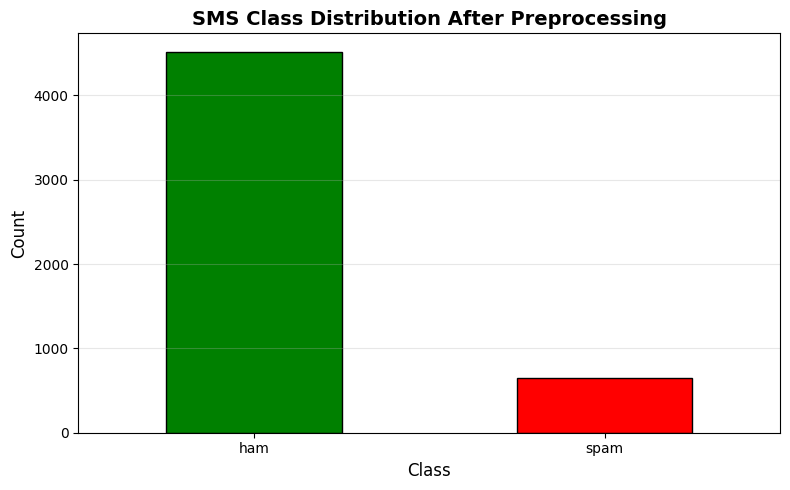


Sample preprocessed messages:
                                             message label  label_encoded
0  go until jurong point, crazy.. available only ...   ham              0
1                      ok lar... joking wif u oni...   ham              0
2  free entry in 2 a wkly comp to win fa cup fina...  spam              1


In [4]:
# Preprocessing Step 1: Select Required Columns
df = df[['v1', 'v2']].copy()  # Keep only label and message columns
df.columns = ['label', 'message']  # Rename for clarity

# Preprocessing Step 2: Check Missing Values

missing = df.isnull().sum()
if missing.sum() == 0:
    pass # No specific print needed if no missing values

# Preprocessing Step 3: Remove Duplicates
df = df.drop_duplicates()

# Preprocessing Step 4: Text Cleaning
# Convert to lowercase
df['message'] = df['message'].str.lower()

# Remove extra whitespaces
df['message'] = df['message'].str.strip()
df['message'] = df['message'].apply(lambda x: re.sub(r'\s+', ' ', x))

# Remove very short messages (less than 3 characters)
df = df[df['message'].str.len() > 3]

# Preprocessing Step 5: Label Encoding
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# Preprocessing Step 6: Class Distribution Analysis
class_dist = df['label'].value_counts()
print(f"\n   Class Distribution:")
print(class_dist)
print(f"\n   Percentage:")
print(f"   Ham:  {(class_dist['ham']/len(df)*100):.2f}%")
print(f"   Spam: {(class_dist['spam']/len(df)*100):.2f}%")

# Final Preprocessing Summary
print(f"\nPREPROCESSING SUMMARY")
print(f"Final dataset size: {len(df)} messages")
print(f"Number of classes: 2 (Ham, Spam)")
print(f"Average message length: {df['message'].str.len().mean():.0f} characters")
print(f"Min message length: {df['message'].str.len().min()} characters")
print(f"Max message length: {df['message'].str.len().max()} characters")

# Visualize class distribution
plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', color=['green', 'red'], edgecolor='black')
plt.title('SMS Class Distribution After Preprocessing', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display sample cleaned data
print(f"\nSample preprocessed messages:")
print(df[['message', 'label', 'label_encoded']].head(3))

## 4. Train-Test Split

The dataset is split into training and testing sets (80% train, 20% test) using stratification to maintain the original class distribution in both subsets.

In [5]:
# Split data with stratification to maintain class distribution
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['message'].tolist(),
    df['label_encoded'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

print(f"Training samples: {len(train_texts)}")
print(f"Testing samples: {len(test_texts)}")
print(f"Split ratio: 80% train, 20% test")

Training samples: 4130
Testing samples: 1033
Split ratio: 80% train, 20% test


## 5. Load Tokenizer and Model

Loading the DistilBERT tokenizer and the pre-trained `DistilBertForSequenceClassification` model, configured for binary classification.

In [6]:
# Model configuration
model_name = 'distilbert-base-uncased'
num_labels = 2  # Binary classification: ham or spam

# Load tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

# Load pre-trained model
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
print(f"\nModel Configuration:")
print(f"  - Model type: DistilBERT (Encoder-only)")
print(f"  - Parameters: ~66 million")
print(f"  - Output labels: {num_labels} (ham=0, spam=1)")
print(f"  - Max sequence length: 512 tokens")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model Configuration:
  - Model type: DistilBERT (Encoder-only)
  - Parameters: ~66 million
  - Output labels: 2 (ham=0, spam=1)
  - Max sequence length: 512 tokens


## 6. Tokenization

Text data from the training and testing sets is tokenized using the loaded DistilBERT tokenizer, ensuring truncation and padding for uniform input length.

In [7]:
# Tokenize training data
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

# Tokenize test data
test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

print(f"\nTokenization Details:")
print(f"  - Max length: 128 tokens")
print(f"  - Padding: Applied to make all sequences equal length")
print(f"  - Truncation: Applied to limit sequence length")
print(f"  - Train encodings shape: {train_encodings['input_ids'].shape}")
print(f"  - Test encodings shape: {test_encodings['input_ids'].shape}")

# Show example of tokenization
print(f"\nExample Tokenization:")
sample_text = train_texts[0]
sample_tokens = tokenizer.tokenize(sample_text)
print(f"Original text: {sample_text[:100]}...")
print(f"Tokens (first 20): {sample_tokens[:20]}")
print(f"Number of tokens: {len(sample_tokens)}")


Tokenization Details:
  - Max length: 128 tokens
  - Padding: Applied to make all sequences equal length
  - Truncation: Applied to limit sequence length
  - Train encodings shape: torch.Size([4130, 128])
  - Test encodings shape: torch.Size([1033, 127])

Example Tokenization:
Original text: i wont get concentration dear you know you are my mind and everything :-)...
Tokens (first 20): ['i', 'won', '##t', 'get', 'concentration', 'dear', 'you', 'know', 'you', 'are', 'my', 'mind', 'and', 'everything', ':', '-', ')']
Number of tokens: 17


## 7. Create PyTorch Dataset

Custom PyTorch `Dataset` objects are created for the training and testing sets, encapsulating the tokenized inputs and their corresponding labels.

In [8]:
# Custom Dataset class
class SMSSpamDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create dataset objects
train_dataset = SMSSpamDataset(train_encodings, train_labels)
test_dataset = SMSSpamDataset(test_encodings, test_labels)

print(f"Train dataset created: {len(train_dataset)} samples")
print(f"Test dataset created: {len(test_dataset)} samples")

Train dataset created: 4130 samples
Test dataset created: 1033 samples


## 8. Configure Training

Training arguments are defined, including hyperparameters like number of epochs, batch size, and evaluation strategy. The Hugging Face `Trainer` is then initialized with the model, arguments, and datasets.

In [9]:
# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

print(f"Training Configuration:")
print(f"  - Epochs: 3")
print(f"  - Batch size: 16")
print(f"  - Learning rate: 5e-5 (default)")
print(f"  - Warmup steps: 100")
print(f"  - Weight decay: 0.01")
print(f"  - Evaluation: After each epoch")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Configuration:
  - Epochs: 3
  - Batch size: 16
  - Learning rate: 5e-5 (default)
  - Warmup steps: 100
  - Weight decay: 0.01
  - Evaluation: After each epoch


## 9. Fine-Tuning the Model

The DistilBERT model is fine-tuned on the SMS spam dataset using the configured `Trainer`.

In [10]:
print("Training started... (This may take 5-10 minutes)")
print("-" * 60)

# Fine-tune the model
trainer.train()

print("\nTRAINING COMPLETED SUCCESSFULLY!")

Training started... (This may take 5-10 minutes)
------------------------------------------------------------


Epoch,Training Loss,Validation Loss
1,0.048069,0.040202
2,0.038667,0.039776
3,0.011972,0.037255


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETED SUCCESSFULLY!


## 10. Model Evaluation

The trained model's performance is evaluated on the test dataset using accuracy, precision, recall, and F1-score. A detailed classification report is also generated.

In [11]:
# Make predictions
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)

# Calculate metrics
accuracy = accuracy_score(test_labels, pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels,
    pred_labels,
    average='binary'
)

print(f"\nEVALUATION METRICS:")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Detailed classification report
print(f"\nDETAILED CLASSIFICATION REPORT:")
print("-" * 60)
print(classification_report(
    test_labels,
    pred_labels,
    target_names=['Ham (0)', 'Spam (1)'],
    digits=4
))


EVALUATION METRICS:
Accuracy:  99.23%
Precision: 0.9767
Recall:    0.9618
F1-Score:  0.9692

DETAILED CLASSIFICATION REPORT:
------------------------------------------------------------
              precision    recall  f1-score   support

     Ham (0)     0.9945    0.9967    0.9956       902
    Spam (1)     0.9767    0.9618    0.9692       131

    accuracy                         0.9923      1033
   macro avg     0.9856    0.9793    0.9824      1033
weighted avg     0.9922    0.9923    0.9922      1033



## 11. Confusion Matrix Visualization

A confusion matrix is generated and visualized to provide a clear breakdown of true positives, true negatives, false positives, and false negatives.

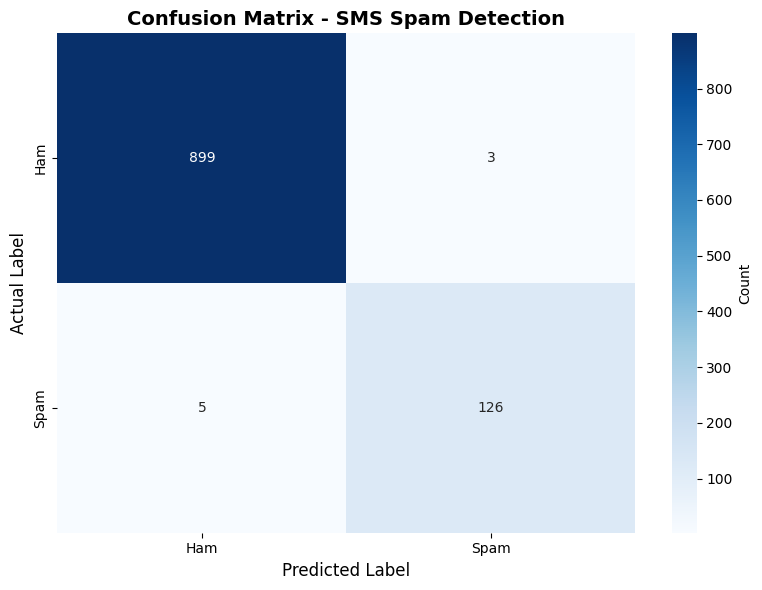


Confusion Matrix Breakdown:
  True Negatives (Correct Ham):   899
  False Positives (Ham as Spam):  3
  False Negatives (Spam as Ham):  5
  True Positives (Correct Spam):  126


In [12]:
# Calculate confusion matrix
cm = confusion_matrix(test_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam'],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - SMS Spam Detection', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (Correct Ham):   {tn}")
print(f"  False Positives (Ham as Spam):  {fp}")
print(f"  False Negatives (Spam as Ham):  {fn}")
print(f"  True Positives (Correct Spam):  {tp}")

## 12. Predict on New Messages

A function `predict_spam` is defined to classify new messages and is tested with several example messages.

In [13]:
# Function to predict new messages
def predict_spam(message):
    """Predict if a message is spam or ham"""
    inputs = tokenizer(
        message,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors='pt'
    )

    # Move inputs to the same device as the model
    inputs = {key: val.to(device) for key, val in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
        prediction = torch.argmax(probabilities, dim=-1).item()
        confidence = probabilities[0][prediction].item()

    label = 'SPAM' if prediction == 1 else 'HAM'
    return label, confidence

# Test with sample messages
test_messages = [
    "Congratulations! You've won a $1000 gift card. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "FREE entry to win iPhone 15! Text WIN to 12345 now!!!",
    "Can you pick up some milk on your way home?",
    "URGENT! Your account will be closed. Verify now: http://fake-link.com"
]

print(f"\nTesting with {len(test_messages)} sample messages:\n")
for i, msg in enumerate(test_messages, 1):
    label, conf = predict_spam(msg)
    print(f"Message {i}:")
    print(f"  Text: {msg[:70]}...")
    print(f"  Prediction: {label}")
    print(f"  Confidence: {conf*100:.2f}%\n")


Testing with 5 sample messages:

Message 1:
  Text: Congratulations! You've won a $1000 gift card. Click here to claim now...
  Prediction: SPAM
  Confidence: 99.87%

Message 2:
  Text: Hey, are we still meeting for lunch tomorrow at 1pm?...
  Prediction: HAM
  Confidence: 99.96%

Message 3:
  Text: FREE entry to win iPhone 15! Text WIN to 12345 now!!!...
  Prediction: SPAM
  Confidence: 99.92%

Message 4:
  Text: Can you pick up some milk on your way home?...
  Prediction: HAM
  Confidence: 99.87%

Message 5:
  Text: URGENT! Your account will be closed. Verify now: http://fake-link.com...
  Prediction: SPAM
  Confidence: 99.77%



## 13. Save the Trained Model

The fine-tuned model and its tokenizer are saved locally for future use.

In [14]:
# Save the trained model
model.save_pretrained('./spam_classifier_model')
tokenizer.save_pretrained('./spam_classifier_model')
print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!
